# Exploratory Data Analysis (EDA): Spotify Music Recommendation

## 1. Project Objectives
The goal of this project is to build a music recommendation system that, given one or more input songs, suggests a list of tracks the user is most likely to enjoy next. 

For the recommendation model, we selected features that describe the sound, mood, musical structure, lyrical characteristics, genre context, and popularity of each track.
The main features used for similarity are:
- acousticness
- danceability
- energy
- instrumentalness
- liveness
- loudness
- speechiness
- tempo
- valence


### 1.1. EDA
This notebook conducts an extensive **Exploratory Data Analysis (EDA)** to evaluate the Spotify dataset for building a content-based music recommendation system. The analysis focuses on:

1. Examining the quality and completeness of the main recommendation features, including audio, lyrical, genre, and popularity-related variables.
2. Exploring the distributions of key audio features such as danceability, energy, acousticness, instrumentalness, loudness, tempo, speechiness, and valence.
3. Investigating artist and genre patterns to understand how musical context can support similarity-based recommendations.

## 2. Setup & Data Loading

In [1]:
import sys
import os
import logging
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Add project root to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Load environment and config (force refresh)
load_dotenv(project_root / '.env', override=True)
from soeSpotify import config

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
palette = sns.color_palette("viridis", as_cmap=False)

print("Setup complete.")

Setup complete.


In [2]:
print("Loading analytical datasets...")

# We use the analytics stage data as it is already cleaned and joined
df_tracks = pd.read_parquet(config.ANALYTICS_TRACKS)
df_artists = pd.read_parquet(config.ANALYTICS_ARTISTS)
df_genres = pd.read_parquet(config.ANALYTICS_GENRES)
df_features = pd.read_parquet(config.ANALYTICS_TRACK_FEATURES)

print(f"Tracks loaded:   {len(df_tracks):,}")
print(f"Artists loaded:  {len(df_artists):,}")
print(f"Genres loaded:   {len(df_genres):,}")
print(f"Features loaded: {len(df_features):,}")

Loading analytical datasets...
Tracks loaded:   101,144
Artists loaded:  56,129
Genres loaded:   87,202
Features loaded: 101,144


# 2.1. Overall feature quality checks

In [3]:
print("Analytics Tracks Shape:")
print(f"Rows: {df_tracks.shape[0]:,}")
print(f"Columns: {df_tracks.shape[1]:,}")

# Audio features selected for the recommendation model
recommendation_features = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
]

# Metadata columns used only for identifying/displaying recommended tracks
metadata_columns = [
    "track_id",
    "track_name",
    "artist_name",
    "album_name",
    "uri",
    "preview_url",
    "release_date",
]

# Check which selected features are available in the dataset
available_features = [
    col for col in recommendation_features
    if col in df_tracks.columns
]

missing_features = [
    col for col in recommendation_features
    if col not in df_tracks.columns
]

print("\nAvailable recommendation features:")
print(available_features)

print("\nMissing recommendation features:")
print(missing_features)

# Summary of selected recommendation features
feature_quality = pd.DataFrame({
    "feature": available_features,
    "data_type": [df_tracks[col].dtype for col in available_features],
    "missing_count": [df_tracks[col].isna().sum() for col in available_features],
    "missing_percent": [df_tracks[col].isna().mean() * 100 for col in available_features],
    "zero_count": [(df_tracks[col] == 0).sum() for col in available_features],
    "zero_percent": [(df_tracks[col] == 0).mean() * 100 for col in available_features],
    "unique_values": [df_tracks[col].nunique(dropna=True) for col in available_features],
})

feature_quality["missing_percent"] = feature_quality["missing_percent"].round(2)
feature_quality["zero_percent"] = feature_quality["zero_percent"].round(2)

display(feature_quality.sort_values("missing_percent", ascending=False))

Analytics Tracks Shape:
Rows: 101,144
Columns: 33

Available recommendation features:
['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

Missing recommendation features:
[]


,feature,data_type,missing_count,missing_percent,zero_count,zero_percent,unique_values
0,acousticness,float64,0,0.0,53,0.05,4704
1,danceability,float64,0,0.0,366,0.36,1207
2,energy,float64,0,0.0,31,0.03,2350
3,instrumentalness,float64,0,0.0,34989,34.59,5374
4,liveness,float64,0,0.0,120,0.12,1718
5,loudness,float64,0,0.0,1,0.00,22438
6,speechiness,float64,0,0.0,366,0.36,1642
7,tempo,float64,0,0.0,366,0.36,51690
8,valence,float64,0,0.0,385,0.38,1781


In [4]:
#  Check duplicate tracks
duplicate_track_ids = df_tracks["track_id"].duplicated().sum()

print("\nDuplicate track_id count:")
print(duplicate_track_ids)


# Check essential metadata needed for recommendations
essential_columns = [
    "track_id",
    "track_name",
    "artist_name",
]

available_essential_columns = [
    col for col in essential_columns
    if col in df_tracks.columns
]

missing_essential_columns = [
    col for col in essential_columns
    if col not in df_tracks.columns
]

print("\nAvailable essential metadata columns:")
print(available_essential_columns)

print("\nMissing essential metadata columns:")
print(missing_essential_columns)

essential_quality = pd.DataFrame({
    "column": available_essential_columns,
    "missing_count": [
        df_tracks[col].isna().sum()
        for col in available_essential_columns
    ],
    "missing_percent": [
        df_tracks[col].isna().mean() * 100
        for col in available_essential_columns
    ],
})

essential_quality["missing_percent"] = essential_quality["missing_percent"].round(2)

print("\nEssential metadata quality:")
display(essential_quality)




Duplicate track_id count:
0

Available essential metadata columns:
['track_id', 'track_name', 'artist_name']

Missing essential metadata columns:
[]

Essential metadata quality:


,column,missing_count,missing_percent
0,track_id,0,0.0
1,track_name,0,0.0
2,artist_name,1,0.0


In [5]:
# Summary for selected audio recommendation features
numeric_features = [
    col for col in available_features
    if pd.api.types.is_numeric_dtype(df_tracks[col])
]

numeric_summary = df_tracks[numeric_features].describe().T

numeric_summary["missing_count"] = df_tracks[numeric_features].isna().sum()
numeric_summary["missing_percent"] = (
    df_tracks[numeric_features].isna().mean() * 100
).round(2)

display(numeric_summary)


# Check zero values in selected audio recommendation features
zero_summary = pd.DataFrame({
    "feature": numeric_features,
    "zero_count": [
        (df_tracks[col] == 0).sum()
        for col in numeric_features
    ],
    "zero_percent": [
        (df_tracks[col] == 0).mean() * 100
        for col in numeric_features
    ],
})

zero_summary["zero_percent"] = zero_summary["zero_percent"].round(2)

display(zero_summary.sort_values("zero_percent", ascending=False))



,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percent
acousticness,101144.0,0.350825,0.334480,0.0,0.0404,0.236000,0.64200,0.996,0,0.0
danceability,101144.0,0.586092,0.177726,0.0,0.4800,0.610000,0.71425,0.989,0,0.0
energy,101144.0,0.587379,0.259669,0.0,0.4130,0.629000,0.79800,1.000,0,0.0
instrumentalness,101144.0,0.148563,0.303841,0.0,0.0000,0.000038,0.03420,1.000,0,0.0
liveness,101144.0,0.197468,0.175252,0.0,0.0955,0.124000,0.24100,0.999,0,0.0
loudness,101144.0,-9.435085,6.174814,-60.0,-11.1120,-7.586000,-5.50400,2.719,0,0.0
speechiness,101144.0,0.127921,0.201612,0.0,0.0364,0.050600,0.10300,0.969,0,0.0
tempo,101144.0,118.392311,30.219922,0.0,95.9830,118.091000,136.05325,244.035,0,0.0
valence,101144.0,0.482698,0.261573,0.0,0.2710,0.477000,0.69300,0.993,0,0.0


,feature,zero_count,zero_percent
3,instrumentalness,34989,34.59
8,valence,385,0.38
7,tempo,366,0.36
6,speechiness,366,0.36
1,danceability,366,0.36
4,liveness,120,0.12
0,acousticness,53,0.05
2,energy,31,0.03
5,loudness,1,0.00


The selected audio features are complete, with no missing values and no missing feature columns, making them suitable for a content-based recommendation model. The dataset also has no duplicate track_id values, and essential metadata is almost fully complete, with only one missing artist_name. Some zero values appear in features such as instrumentalness, which is expected because many songs are not instrumental.

Important: All features should be scaled before similarity modeling because the features are measured on different ranges.

## 3. Univariate Analysis: Understanding Individual Features

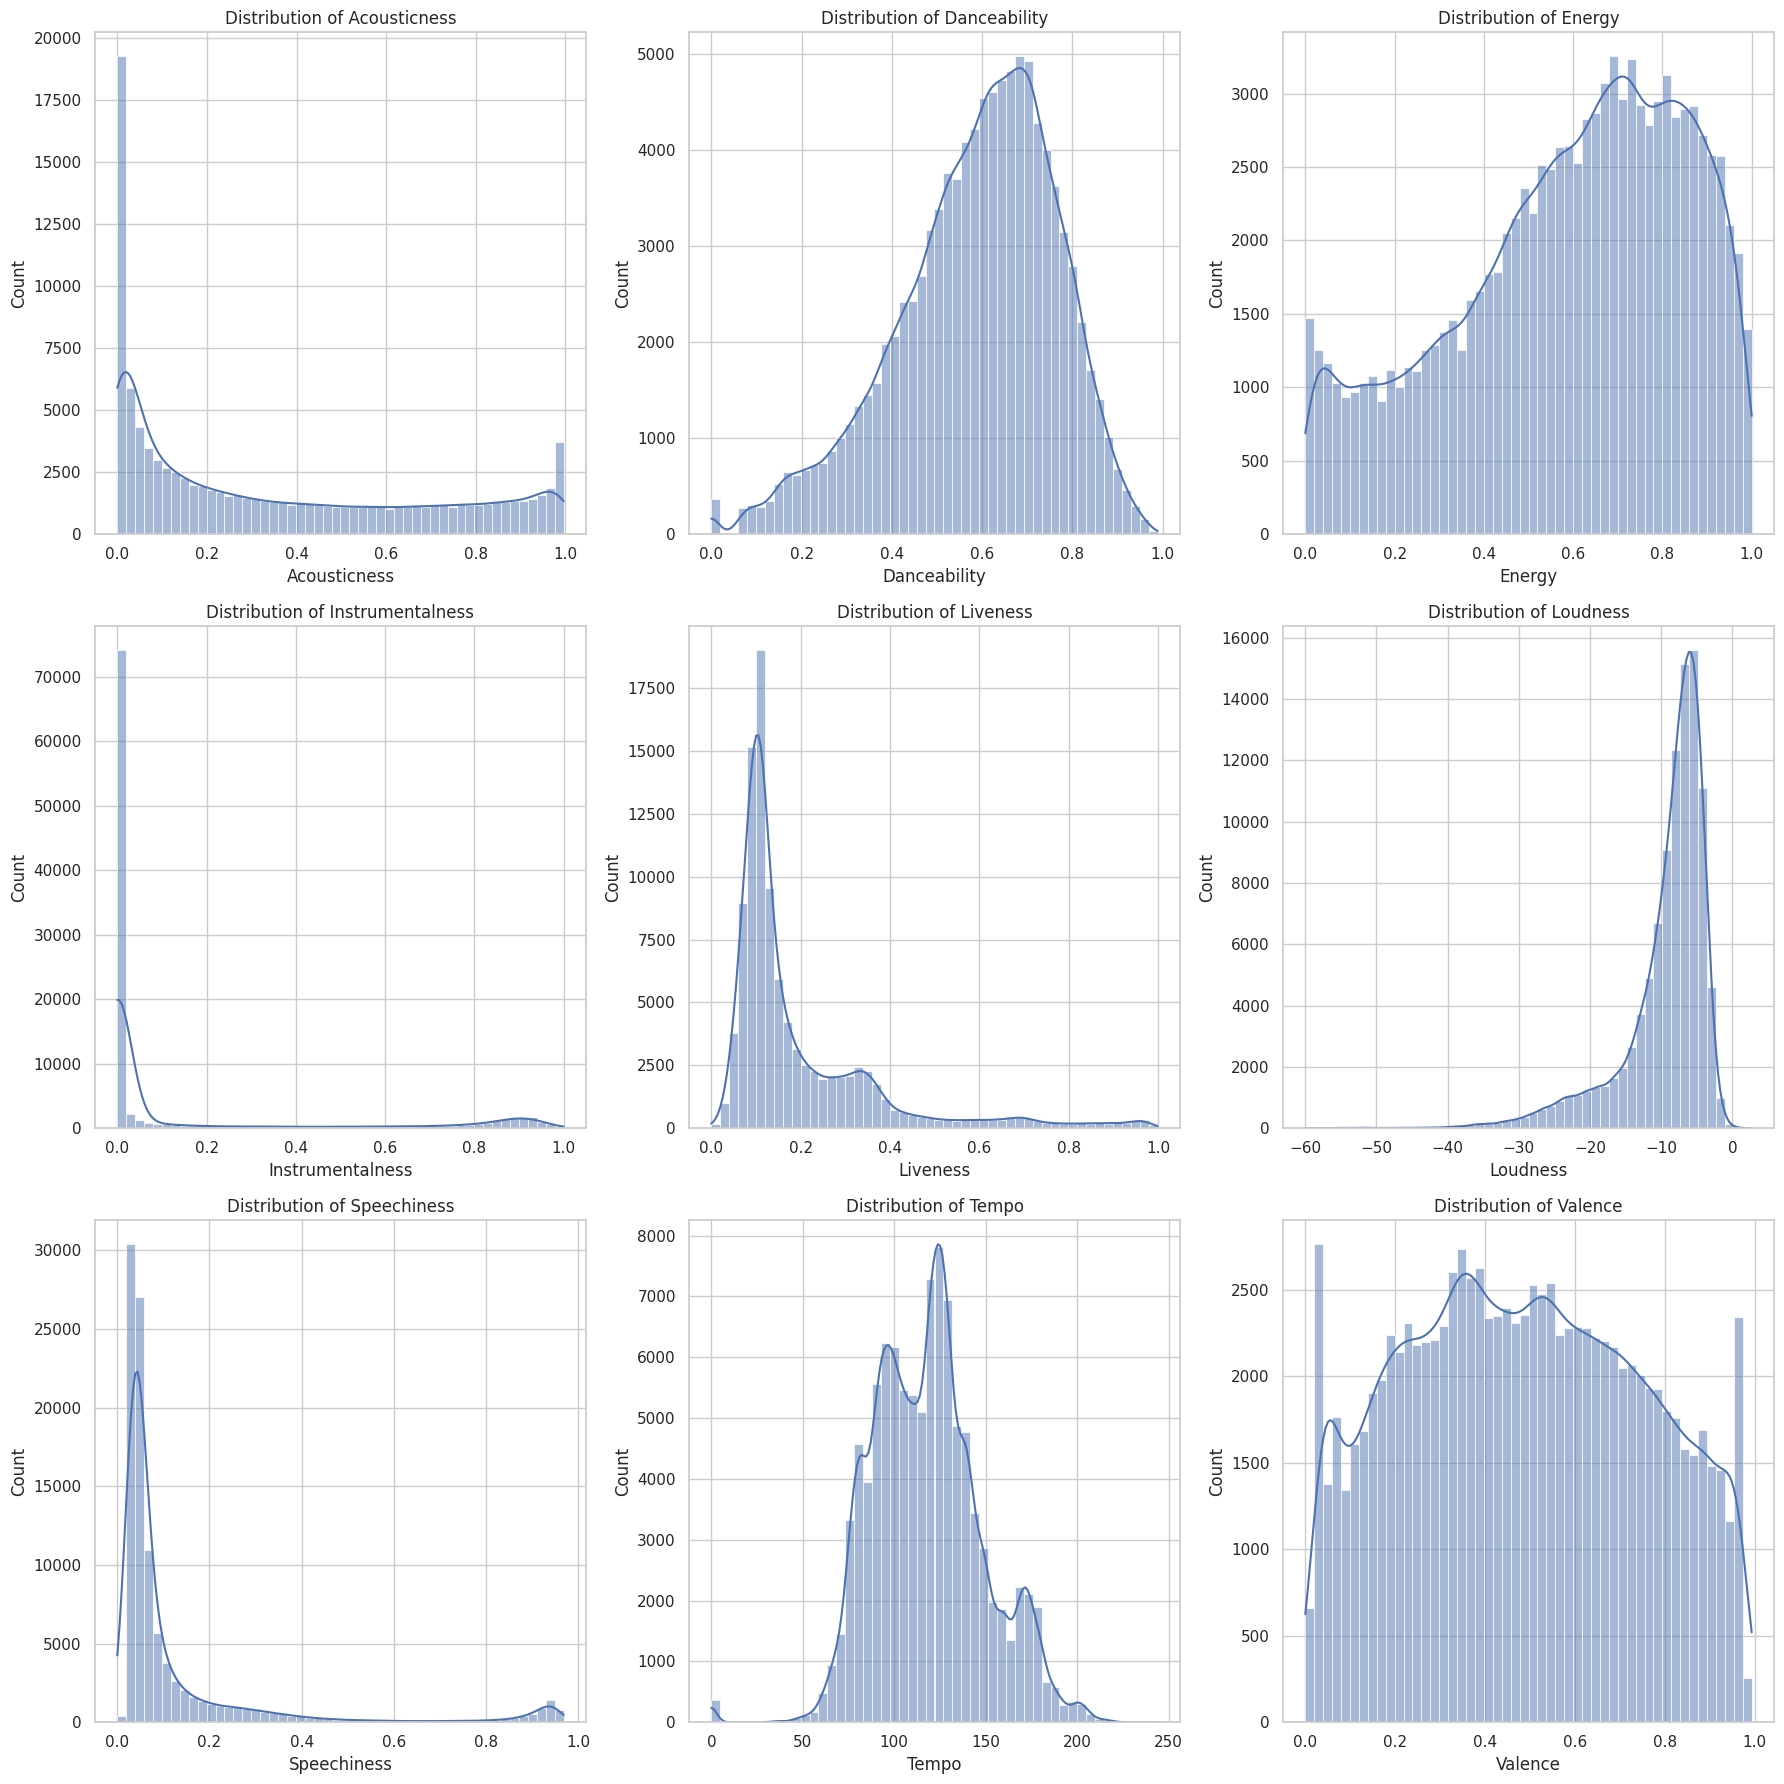

In [6]:
selected_audio_features = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
]

if not df_tracks.empty:
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    axes = axes.flatten()

    for i, feature in enumerate(selected_audio_features):
        sns.histplot(
            df_tracks[feature].dropna(),
            bins=50,
            kde=True,
            ax=axes[i]
        )

        axes[i].set_title(f"Distribution of {feature.replace('_', ' ').title()}")
        axes[i].set_xlabel(feature.replace("_", " ").title())
        axes[i].set_ylabel("Count")

    for j in range(len(selected_audio_features), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

else:
    print("No tracks data available.")

- **Acousticness**: Most tracks have low acousticness, meaning the dataset contains many tracks that sound less natural or live then tracks that sound more amplified. There is also a smaller group of highly acoustic tracks near 1.0.
- **Danceability**: Danceability is mostly concentrated between 0.4 and 0.8, showing that many tracks are moderately to highly danceable.
- **Energy**: Energy is generally high, with many songs between 0.5 and 0.9, suggesting the dataset contains many intense or active tracks.
- **Instrumentalness**: Most tracks have instrumentalness close to 0, meaning they likely contain vocals. Only a smaller group appears to be highly instrumental.
- **Liveness**: Most songs have low liveness values, meaning they are likely studio recordings rather than live performances.
- **Loudness**: Loudness is concentrated around higher values, roughly between -12 and -4 dB, with fewer very quiet tracks.
- **Speechiness**: Most tracks have low speechiness, meaning they are mostly musical rather than spoken-word or rap-heavy.
- **Tempo**: Tempo is centered mostly around 90–150 BPM, with clear peaks around common popular music tempos.
- **Valence**: Valence is spread across the full range, meaning the dataset contains both sad/darker and happy/positive sounding songs.

Overall the graphs show that the dataset consists mainly of studio-produced, vocal-based tracks, with generally low acousticness, instrumentalness, liveness, and speechiness. At the same time, many songs are moderately to highly danceable and energetic, with a wide range of emotional tone shown by the spread of valence values.

## 4. Bivariate & Multivariate Analysis

### 4.1. Audio Feature Correlations
Understanding which features move together.

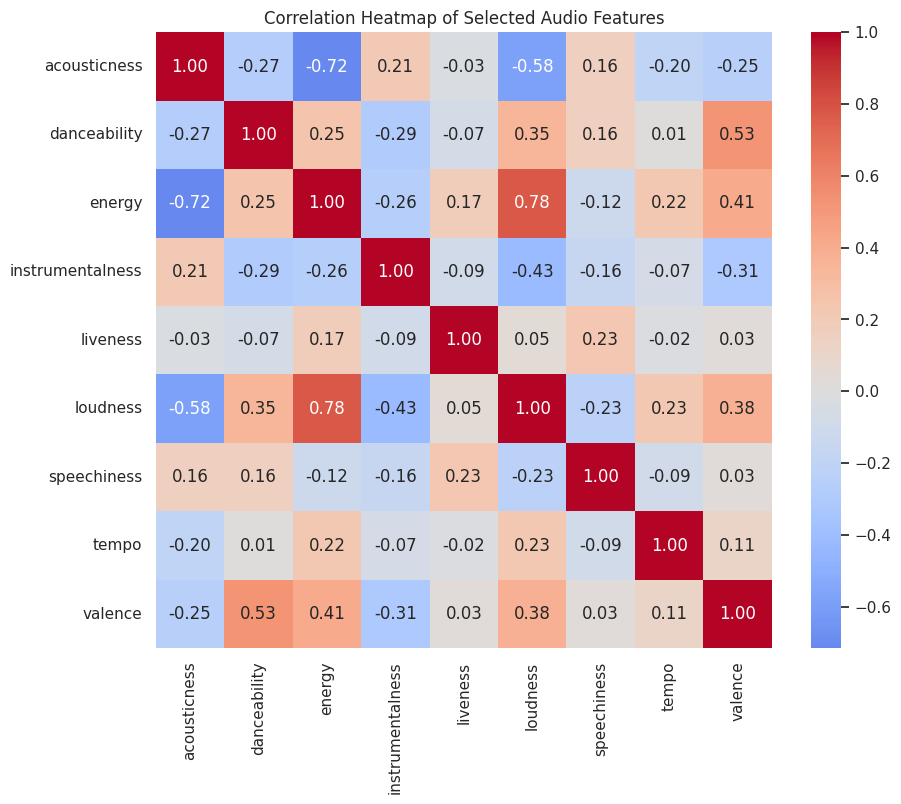

In [7]:
df_audio = df_tracks[selected_audio_features].copy()
plt.figure(figsize=(10, 8))

corr_matrix = df_audio.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap of Selected Audio Features")
plt.show()

The strongest features that move together positively are:
- energy + loudness: 0.78
- danceability + valence: 0.53
- energy + valence: 0.41
- loudness + valence: 0.38
- danceability + loudness: 0.35

This means that louder songs tend to be more energetic it is. More danceable songs tend to sound more positive/happy and higher-energy songs also tend to have higher valence.

The strongest features that move in opposite directions are:
- acousticness + energy: -0.72
- acousticness + loudness: -0.58
- instrumentalness + loudness: -0.43
- instrumentalness + valence: -0.31
- danceability + instrumentalness: -0.29

This means that more acoustic songs tend to be less energetic and quieter, while more instrumental tracks tend to be less loud, less danceable, and slightly less positive. 

Overall, the clearest relationship is that energy and loudness strongly move together, while acousticness moves strongly against energy and loudness.

### 4.2. Energy vs. Loudness vs. Acousticness


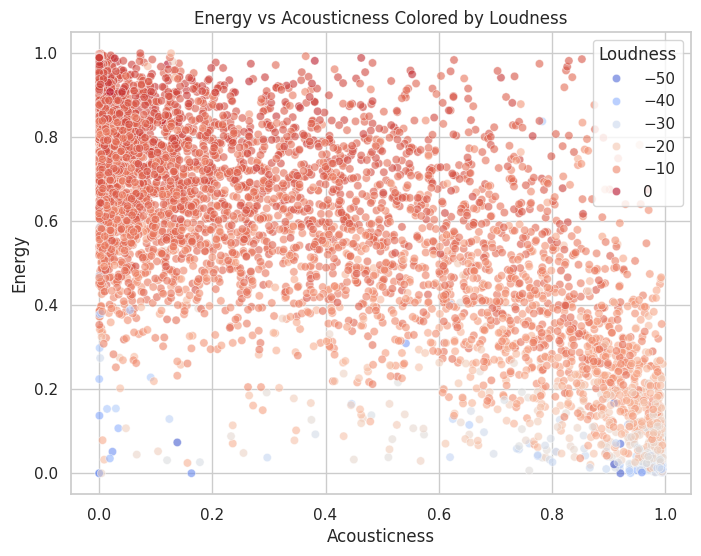

In [8]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_tracks.sample(5000, random_state=1000),
    x="acousticness",
    y="energy",
    hue="loudness",
    palette="coolwarm",
    alpha=0.6
)

plt.title("Energy vs Acousticness Colored by Loudness")
plt.xlabel("Acousticness")
plt.ylabel("Energy")
plt.legend(title="Loudness")
plt.show()

The plot shows that tracks with low acousticness cover a wide range of energy levels, but many of them are highly energetic. As acousticness increases, the density of high-energy tracks becomes lower, suggesting that more acoustic songs are generally less energetic, while louder tracks tend to appear more often in the higher-energy areas.

### 4.3. Energy vs. Valence (Mood Mapping)
This visualisation shows the information regarding mood mapping: high energy + high valence = Happy/Excited; high energy + low valence = Angry/Stressed.

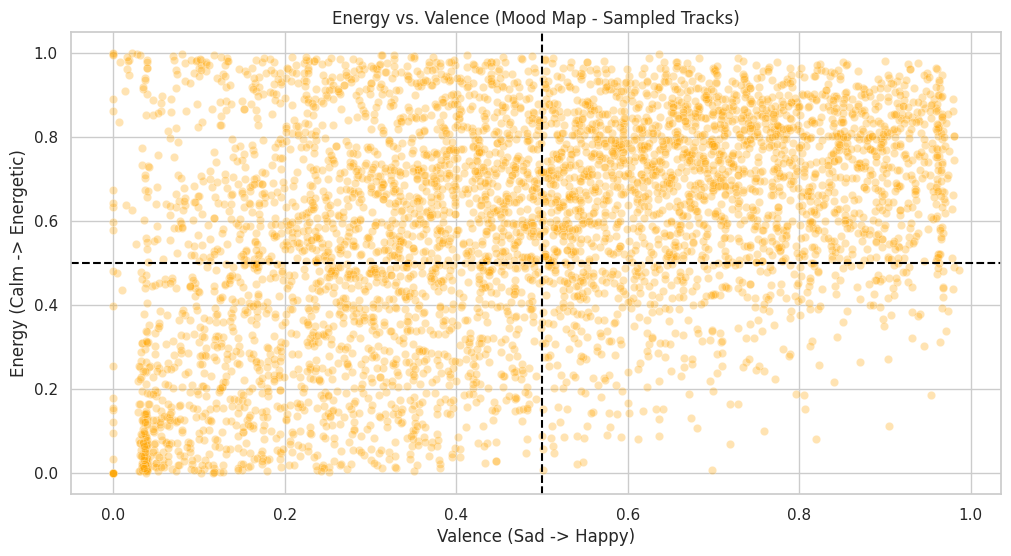

In [9]:
if not df_features.empty:
    sns.scatterplot(data=df_features.sample(n=min(5000, len(df_features))), x='valence', y='energy', alpha=0.3, color='orange')
    plt.axhline(0.5, color='black', linestyle='--')
    plt.axvline(0.5, color='black', linestyle='--')
    plt.title('Energy vs. Valence (Mood Map - Sampled Tracks)')
    plt.xlabel('Valence (Sad -> Happy)')
    plt.ylabel('Energy (Calm -> Energetic)')
    plt.show()
else:
    print("No features data available.")

This plot shows that the dataset contains tracks across all mood types, from low-valence “sadder” songs to high-valence “happier” songs, and from calm to energetic tracks. The upper-right area is especially dense, suggesting many songs are both energetic and relatively positive in mood.

## 5. Genre & Artist Analysis

### 5.1. Top 10 Genres
Identify the most frequent genres in our dataset.

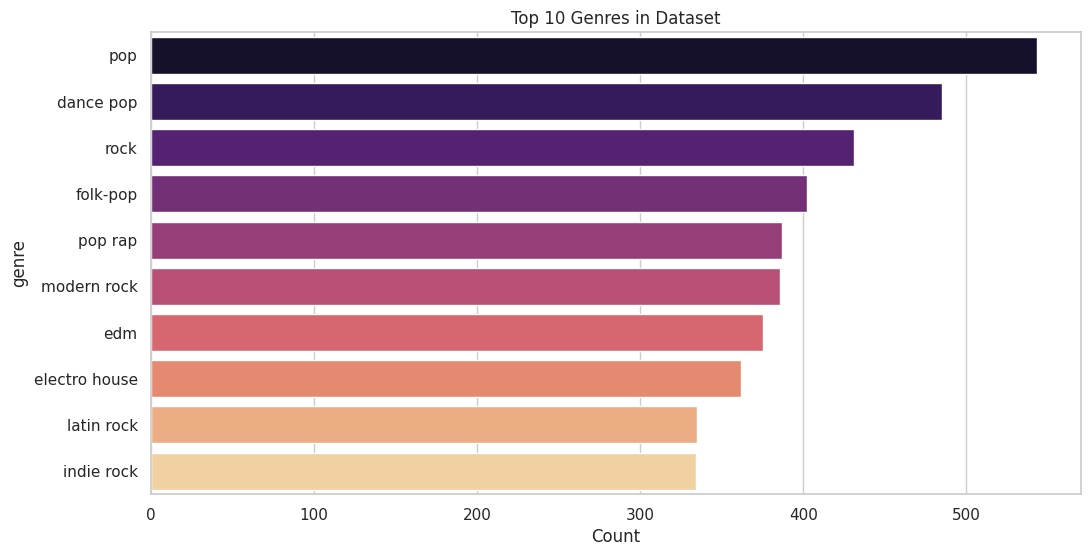

In [31]:
if not df_genres.empty:
    top_genres = df_genres['genre'].value_counts().head(10)
    sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='magma', legend=False)
    plt.title('Top 10 Genres in Dataset')
    plt.xlabel('Count')
    plt.show()
else:
    print("No genre data available.")

### 5.2. Top 10 artists by number of tracks

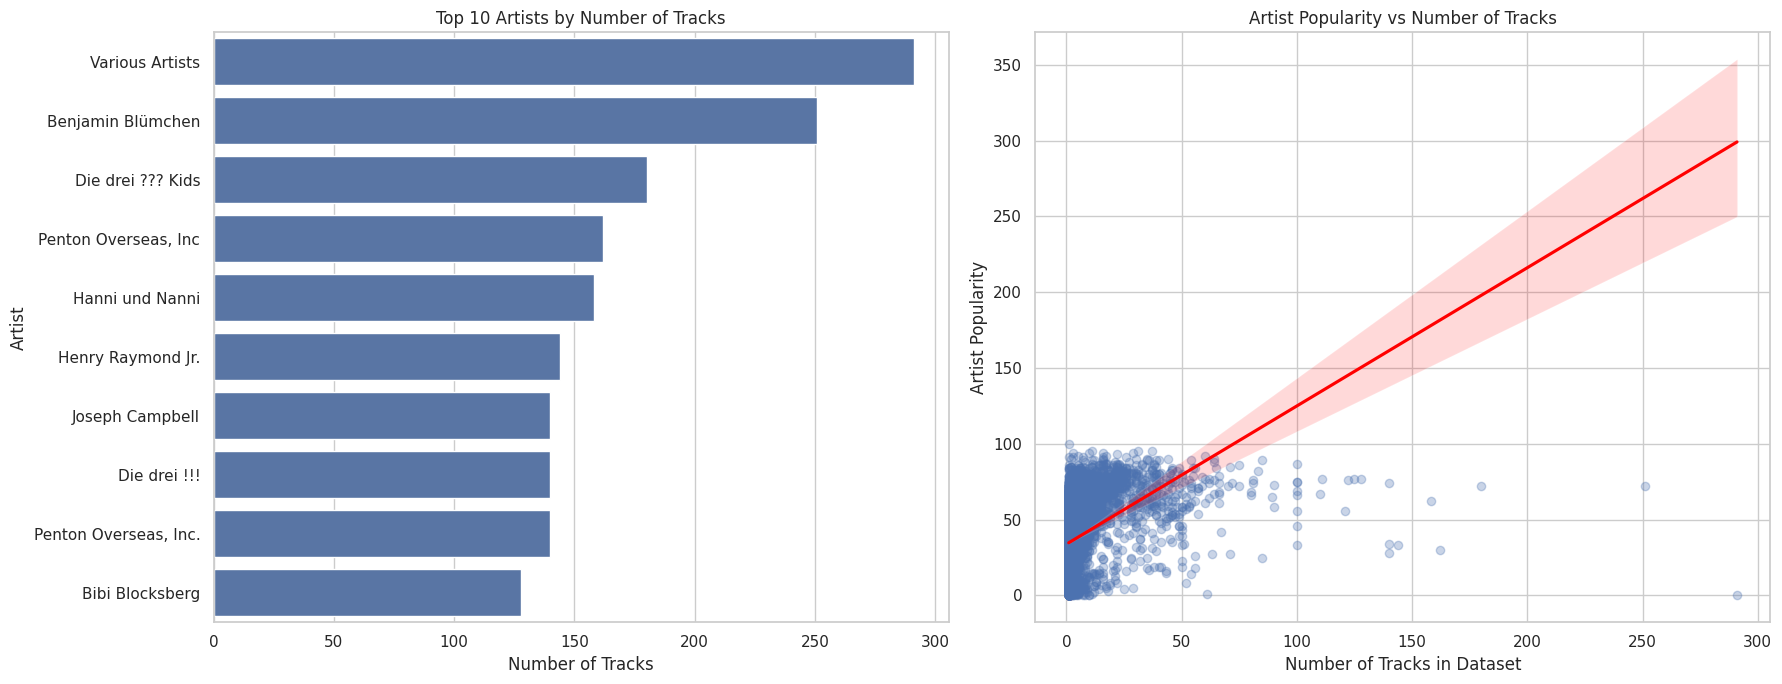

Correlation between number of tracks and artist popularity: 0.30


In [ ]:
# Count how many unique tracks each artist has
artist_track_counts = (
    df_tracks
    .groupby("artist_name")["track_id"]
    .nunique()
    .reset_index(name="track_count")
)

# Get artist popularity
artist_popularity = (
    df_tracks
    .groupby("artist_name")["artist_popularity"]
    .max()
    .reset_index()
)

# Merge track count and popularity
artist_analysis = artist_track_counts.merge(
    artist_popularity,
    on="artist_name",
    how="left"
)

# oremove extreme values
# artist_analysis = artist_analysis[artist_analysis["track_count"] <= 200].copy()


# Top 10 artists by number of tracks
top_artists_by_tracks = (
    artist_analysis
    .sort_values("track_count", ascending=False)
    .head(10)
)

# Create 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10 artists by number of tracks
sns.barplot(
    data=top_artists_by_tracks,
    x="track_count",
    y="artist_name",
    ax=axes[0]
)

axes[0].set_title("Top 10 Artists by Number of Tracks")
axes[0].set_xlabel("Number of Tracks")
axes[0].set_ylabel("Artist")

# Artist popularity vs number of tracks
sns.regplot(
    data=artist_analysis,
    x="track_count",
    y="artist_popularity",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[1]
)

axes[1].set_title("Artist Popularity vs Number of Tracks")
axes[1].set_xlabel("Number of Tracks in Dataset")
axes[1].set_ylabel("Artist Popularity")

plt.tight_layout()
plt.show()

# Correlation
correlation = artist_analysis["track_count"].corr(
    artist_analysis["artist_popularity"]
)

print(f"Correlation between number of tracks and artist popularity: {correlation:.2f}")

### 5.3. Top artists by followers vs. Popularity

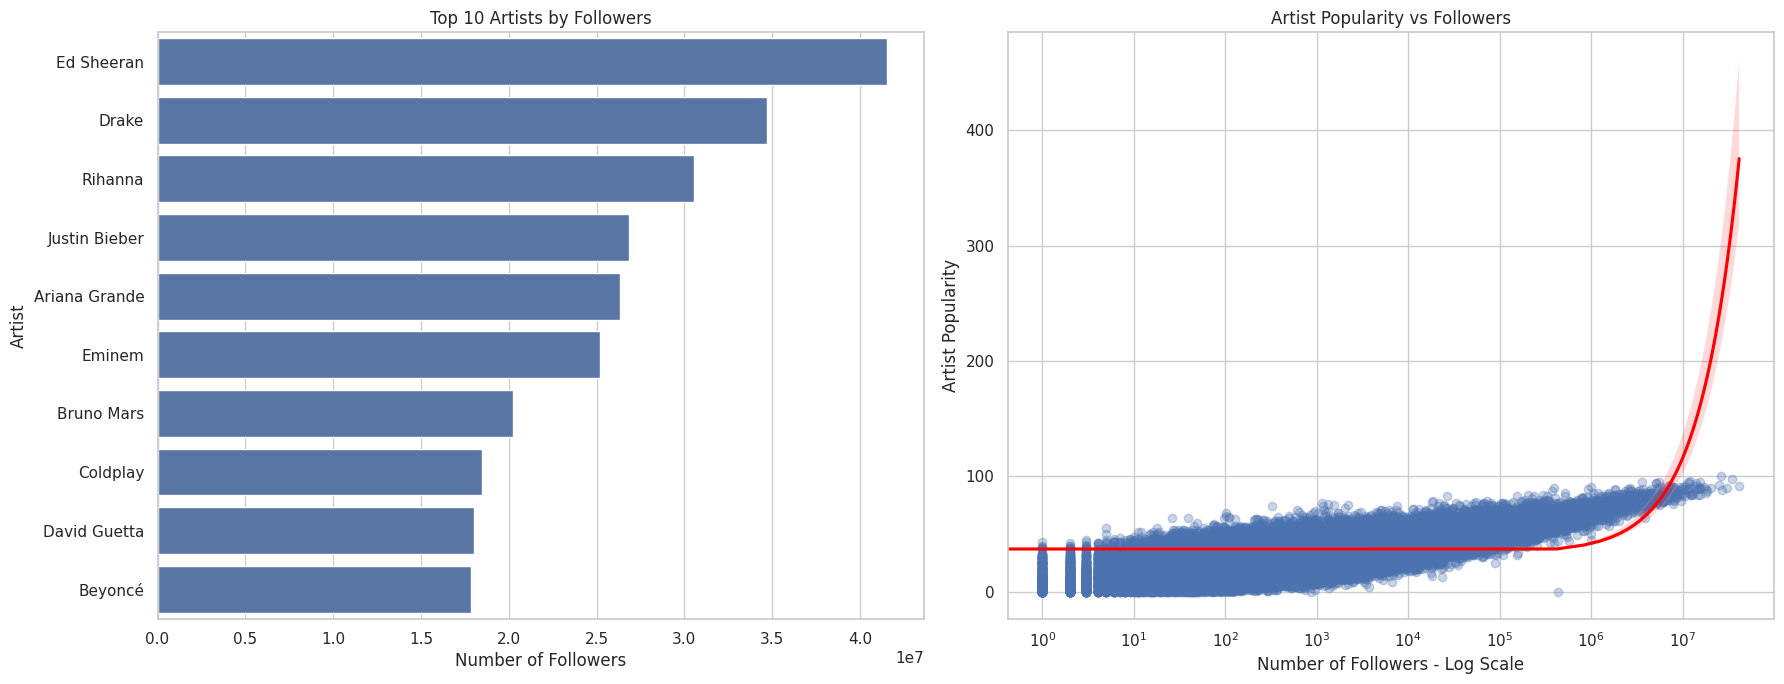

In [18]:
# Top 10 artists by followers
top_artists_by_followers = (
    df_artists
    .sort_values("followers", ascending=False)
    [["artist_name", "followers", "artist_popularity"]]
    .head(10)
)

# Create 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=top_artists_by_followers,
    x="followers",
    y="artist_name",
    ax=axes[0]
)

axes[0].set_title("Top 10 Artists by Followers")
axes[0].set_xlabel("Number of Followers")
axes[0].set_ylabel("Artist")

# Artist popularity vs followers

sns.regplot(
    data=df_artists,
    x="followers",
    y="artist_popularity",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[1]
)

axes[1].set_xscale("log")
axes[1].set_title("Artist Popularity vs Followers")
axes[1].set_xlabel("Number of Followers - Log Scale")
axes[1].set_ylabel("Artist Popularity")

plt.tight_layout()
plt.show()


## 6. Research Findings: Recommendation Model Options

Based on the dataset of approximately 100,000 tracks and the selected Spotify audio features, the recommendation system will focus on content-based approaches. Since no user interaction data, ratings, likes, or listening history are available, the models should recommend songs based on audio similarity rather than user behavior.

### Option A: Content-Based Filtering using Cosine Similarity
- **Concept**: Represent each track as a vector of selected audio features and calculate cosine similarity between the input song and all other tracks.
- **Pros**: Simple, explainable, scalable, and suitable when no user interaction data is available. It works well for recommending songs with a similar audio profile.
- **Cons**: May recommend songs that are very similar and may lack diversity or serendipity.
- **Implementation**: Scale the selected audio features and use cosine similarity to rank tracks by similarity score.

### Option B: K-Nearest Neighbors (KNN)
- **Concept**: Find the tracks that are closest to the input song in the scaled audio feature space using a distance metric such as cosine or Euclidean distance.
- **Pros**: Easy to understand, directly matches the goal of finding similar songs, and can be tuned by changing the number of neighbors or distance metric.
- **Cons**: Can become slower at query time for larger datasets if no indexing or approximate nearest neighbor method is used.
- **Implementation**: Use `scikit-learn`’s `NearestNeighbors` on the scaled audio feature matrix.

--- 

## 7. Potential Issues & Limitations
1. New songs without audio feature extraction cannot be recommended.
2. **Feature Scaling**: Numerical features (Tempo vs. Acousticness) have different scales and must be normalized before distance calculations.
3. **Popularity Bias**: Models might over-recommend the most popular artists (e.g., Ariana Grande, Drake) if popularity is included as a feature.

## 8. Next Steps

1. Implement a Feature Scaling pipeline.
2. Prototype a Content-Based Recommender using Cosine Similarity.
3. Build a Streamlit demo for real-time interaction.